# **TP4 - Principal Component Analysis (PCA)**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Course: Dr. Sothea HAS** <br> 
**TP: Mr. UANN Sreyvi**

-------

**Objective**: In this lab, let's dive into an essential unsupervised learning method: Principal Component Analysis (PCA). PCA is a key technique for dimensionality reduction that simplifies data while preserving its crucial patterns. We will explore PCA from multiple perspectives in this TP.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP4_PCA.ipynb](https://hassothea.github.io/EDA_ITC/TPs/TP4_PCA.ipynb)**.

-------

## 1. Analyzing US Crime Dataset with PCA

The `USArrests` data available in `Kaggle` provides statistics on arrests for crime including **rape**, **assault** and **murder** in 50 states of the United States in 1973. 

For information, read about the dataset [here](https://www.kaggle.com/datasets/halimedogan/usarrests). We will use PCA to identify which U.S. state was the most dangerous or the safest in 1973.

**A.** Import the data and visualize each column to get a general sense of the dataset.

In [82]:
import pandas as pd

df = pd.read_csv("USArrests.csv")
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [83]:
df.columns

Index(['Unnamed: 0', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [84]:
# rename and lowercase column name
df.rename(columns={'Unnamed: 0' : 'state'}, inplace=True)
df.columns = df.columns.str.lower()

**B.** Study correlations between columns of the data using both `Pearson` and `Spearman` correlation coefficients.

- Create pairplot for all columns of the data.

- Given such a pairplot and based on correlations above, is it a good idea to perform dimensional reduction on this dataset? Why?



In [85]:
num_df = df.select_dtypes(include="number")

display(
    num_df.corr().style
        .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
        .format("{:.3f}")
        .set_caption("Pearson Correlation")
)

display(
    num_df.corr(method='spearman').style
        .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
        .format("{:.3f}")
        .set_caption("Spearman Correlation")
)

,murder,assault,urbanpop,rape
murder,1.000,0.802,0.070,0.564
assault,0.802,1.000,0.259,0.665
urbanpop,0.070,0.259,1.000,0.411
rape,0.564,0.665,0.411,1.000


,murder,assault,urbanpop,rape
murder,1.000,0.817,0.107,0.679
assault,0.817,1.000,0.275,0.714
urbanpop,0.107,0.275,1.000,0.438
rape,0.679,0.714,0.438,1.000


> there is multicolinearity => performing dimensional reduction is a good idea

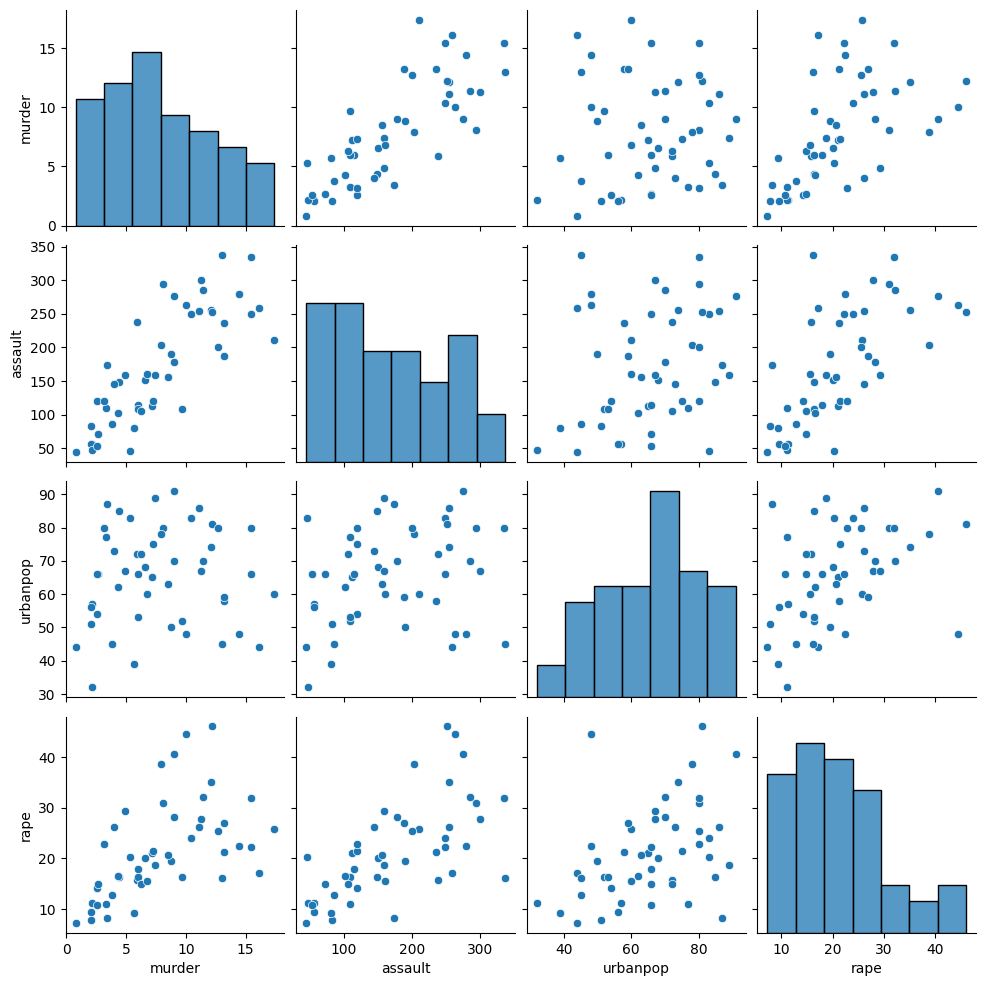

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.pairplot(data=df)
plt.show()

**C.** Perform reduced PCA (scaled and centered data) on this dataset.

- Create the scree plot of explained variances of the data.

- How many percentage of explained variance is retained by the first two principal components?

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=['state'])
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [88]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca)
pca_df['state'] = df['state']

explained_var = pca.explained_variance_ratio_
print("Explained variance ratio per component:", explained_var)

Explained variance ratio per component: [0.62006039 0.24744129 0.0891408  0.04335752]


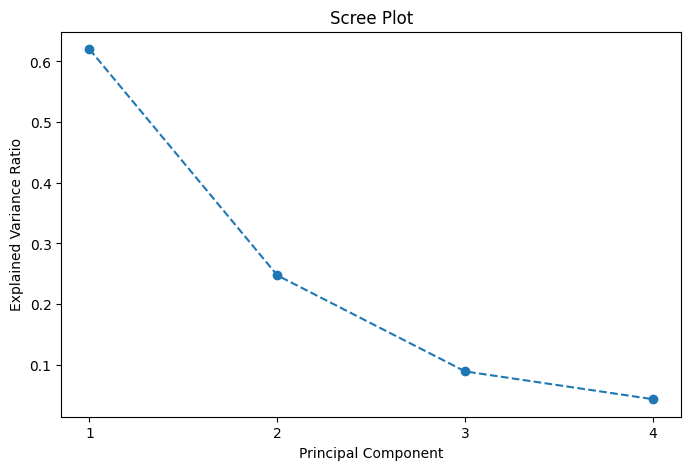

In [89]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_var)+1))
plt.show()

In [90]:
var_first_two = explained_var[0] + explained_var[1]
print(f"Variance explained by first 2 PCs: {var_first_two*100:.2f}%")

Variance explained by first 2 PCs: 86.75%


**D.** Create circle of correlation of the obtained PCA. Explain this correlation circle.

- Compute the contribution of original variables on the first two PCs (loadings).

- Compute the contribution of each individual on the first two PCs.

In [91]:
pca.components_

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

In [92]:
import numpy as np

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
corr_circle = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=X.columns)

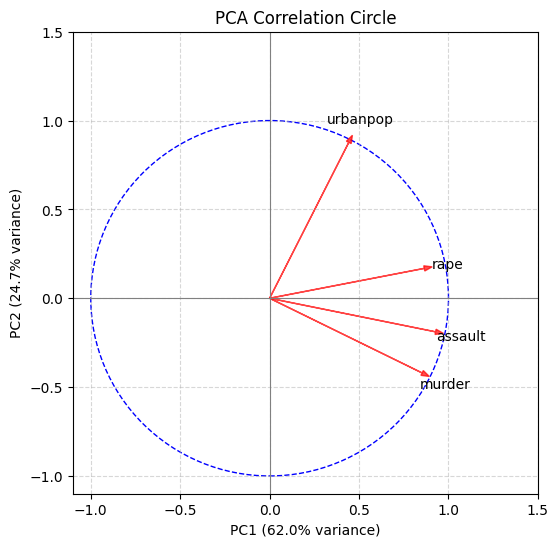

In [93]:
plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)

# Draw the circle (unit radius)
circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Plot variable vectors
for i, var in enumerate(corr_circle.index):
    x = corr_circle.iloc[i, 0]
    y = corr_circle.iloc[i, 1]
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, head_width=0.03)
    plt.text(x*1.15, y*1.15, var, color='black', ha='center', va='center', fontsize=10)

# Labels and title
plt.title('PCA Correlation Circle')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.xlim(-1.1, 1.5)
plt.ylim(-1.1, 1.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**E.** Create biplot of the data on the first factorial plan (PC1 and PC2). Based on this biplot, which US state in 1973 was

- the most dangerous?
- the safest?
- the highly urbanized?
- Verify your answer by checking the situation of those states.

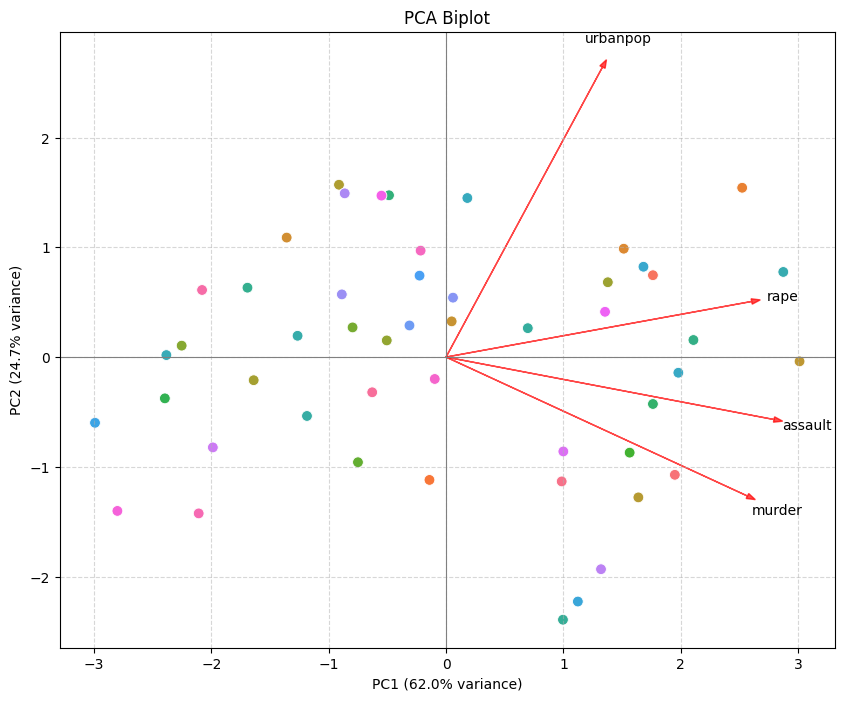

In [94]:
df['PC1'] = pca_df[0]
df['PC2'] = pca_df[1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='state', s=60, legend=False)

max_score = np.max(np.abs(df[['PC1','PC2']].values))
for i, var in enumerate(corr_circle.index):
    x = corr_circle.iloc[i, 0] * max_score
    y = corr_circle.iloc[i, 1] * max_score
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, head_width=0.05)
    plt.text(x*1.1, y*1.1, var, color='black', ha='center', va='center', fontsize=10)

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title('PCA Biplot')
plt.show()


Using this plot, we can interprete it:
- Rape, Assault, Murder correlate, therefore belongs to one PC
- Urbanpop belongs to another PC

In [95]:
display(
    df
    .sort_values('PC1', ascending=False)
    .head(5)[['state', 'murder', 'assault', 'rape']]
    .style.set_caption('The Most Dangerous States (Highest PC1)')
)

display(
    df
    .sort_values('PC1', ascending=True)
    .head(5)[['state', 'murder', 'assault', 'rape']]
    .style.set_caption('The Safest States (Lowest PC1)')
)

display(
    df
    .sort_values('PC2', ascending=False)
    .head(5)[['state', 'urbanpop']]
    .style.set_caption('The highly urbanized states')
)


,state,murder,assault,rape
8,Florida,15.400000,335,31.900000
27,Nevada,12.200000,252,46.000000
4,California,9.000000,276,40.600000
21,Michigan,12.100000,255,35.100000
30,New Mexico,11.400000,285,32.100000


,state,murder,assault,rape
33,North Dakota,0.800000,45,7.300000
44,Vermont,2.200000,48,11.200000
18,Maine,2.100000,83,7.800000
28,New Hampshire,2.100000,57,9.500000
14,Iowa,2.200000,56,11.300000


,state,urbanpop
10,Hawaii,83
4,California,91
38,Rhode Island,87
20,Massachusetts,85
43,Utah,80


- All PCs are independent
- We can check correlation between original variables with PCS to determine which var is linkedin with which PC

## 2. Analyzing Auto-MPG dataset with PCA

**A.** Import `Auto-MPG` dataset from kaggle, available [here](https://www.kaggle.com/datasets/uciml/autompg-dataset).

- Compute correlation matrix of quantitative columns of this dataset.

In [96]:
import pandas as pd

df = pd.read_csv('auto-mpg.csv')
# replace whitespace with underscore
df.columns = df.columns.str.replace(' ', '_')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [97]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

In [98]:
r = df.query("horsepower == '?'").shape[0]
print(f"Number of rows with horsepower '?': {r}")

Number of rows with horsepower '?': 6


In [99]:
df = df.query('horsepower != "?"')
# change to numeric
df['horsepower'] = df['horsepower'].astype(int)
# change to object
df['origin'] = df['origin'].astype('object')

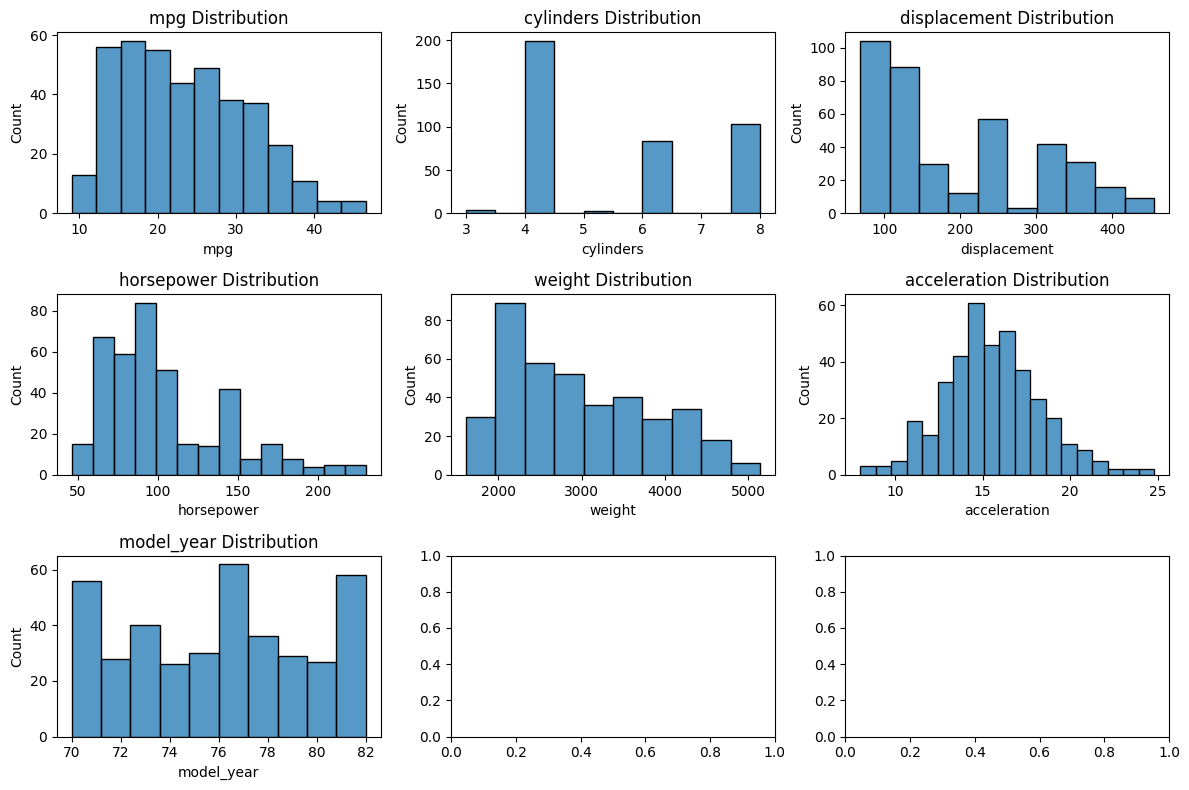

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

num_df = df.select_dtypes(include="number")

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_df.columns):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [101]:
pcorr = num_df.corr()
scorr = num_df.corr(method='spearman')

display(
    pcorr
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format("{:.3f}")
    .set_caption("Pearson Corr")
)

display(
    scorr
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format("{:.3f}")
    .set_caption("Spearman Corr")
)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000,-0.778,-0.805,-0.778,-0.832,0.423,0.581
cylinders,-0.778,1.000,0.951,0.843,0.898,-0.505,-0.346
displacement,-0.805,0.951,1.000,0.897,0.933,-0.544,-0.370
horsepower,-0.778,0.843,0.897,1.000,0.865,-0.689,-0.416
weight,-0.832,0.898,0.933,0.865,1.000,-0.417,-0.309
acceleration,0.423,-0.505,-0.544,-0.689,-0.417,1.000,0.290
model_year,0.581,-0.346,-0.370,-0.416,-0.309,0.290,1.000


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000,-0.823,-0.855,-0.854,-0.876,0.442,0.575
cylinders,-0.823,1.000,0.914,0.816,0.876,-0.476,-0.331
displacement,-0.855,0.914,1.000,0.876,0.946,-0.499,-0.307
horsepower,-0.854,0.816,0.876,1.000,0.879,-0.658,-0.389
weight,-0.876,0.876,0.946,0.879,1.000,-0.405,-0.281
acceleration,0.442,-0.476,-0.499,-0.658,-0.405,1.000,0.278
model_year,0.575,-0.331,-0.307,-0.389,-0.281,0.278,1.000


**B.** Perform reduced PCA on this dataset.

- How much information or variation is retained by the first two pCs?

In [102]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop(columns=['car_name', 'origin', 'mpg'])
x_scaled = scaler.fit_transform(X)

pca = PCA()
x_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(x_pca)
pca_df['mpg'] = df['mpg']

explained_var = pca.explained_variance_ratio_

var_first_two = explained_var[0] + explained_var[1]
print(f"Variance explained by first 2 PCs: {var_first_two*100:.2f}%")

Variance explained by first 2 PCs: 84.95%


**C.** Create correlation circle and biplot. Comment.

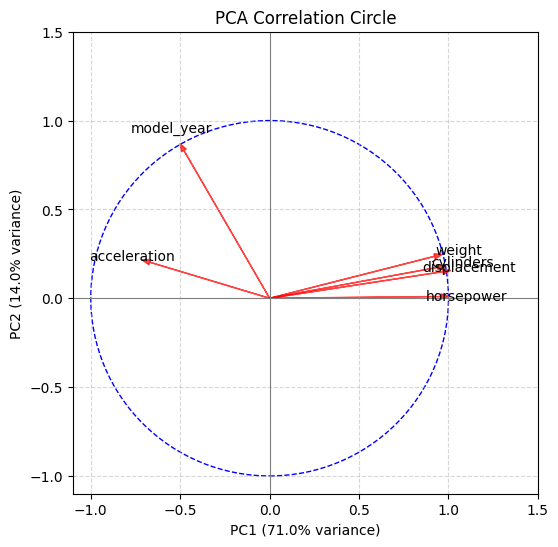

In [103]:
import numpy as np

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
corr_circle = pd.DataFrame(loadings, columns=[f'PC{i}' for i in range(1, 7)], index=X.columns)

plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)

# Draw the circle (unit radius)
circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Plot variable vectors
for i, var in enumerate(corr_circle.index):
    x = corr_circle.iloc[i, 0]
    y = corr_circle.iloc[i, 1]
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, head_width=0.03)
    plt.text(x*1.15, y*1.15, var, color='black', ha='center', va='center', fontsize=10)

# Labels and title
plt.title('PCA Correlation Circle')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.xlim(-1.1, 1.5)
plt.ylim(-1.1, 1.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

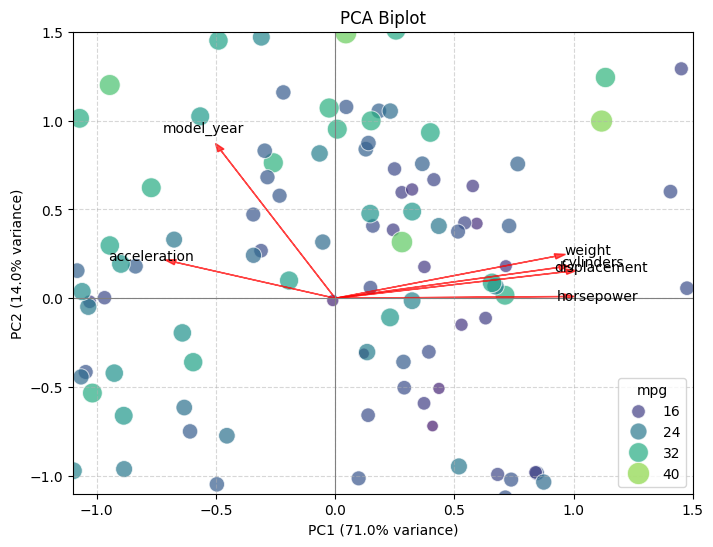

In [104]:
df['PC1'] = pca_df[0]
df['PC2'] = pca_df[1]

plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    size='mpg',              
    sizes=(50, 300),          
    alpha=0.7,
    palette='viridis',       
    hue='mpg',                
    legend='brief'          
)

for i, var in enumerate(corr_circle.index):
    x = corr_circle.iloc[i, 0]
    y = corr_circle.iloc[i, 1]
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, head_width=0.03)
    plt.text(x*1.15, y*1.15, var, color='black', ha='center', va='center', fontsize=10)

# Labels and title
plt.title('PCA Biplot')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.xlim(-1.1, 1.5)
plt.ylim(-1.1, 1.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Mathematical Problem of PCA

From mathematical point of views, PCA can be seen as a process of searching for a subspace with maximum [projection variance](https://en.wikipedia.org/wiki/Principal_component_analysis) of the data points or searching for its closest [low-rank approximation](https://en.wikipedia.org/wiki/Low-rank_approximation).

Suppose we have a design matrix of observations $X\in\mathbb{R}^{n\times d}$ with centered columns. We aim to mathematically define 1st, 2nd,..., $d$ th principal components of this matrix.

**A. First PC:** a vector $\vec{u}_1\in\mathbb{R}^d$ is the $1$ st PC direction of $X$ if it is the direction (unit vector) in which the projection of observations $X$ achieves maximum variance, i.e.,

$$\vec{u}_1=\arg\max_{\vec{u}:\|\vec{u}\|=1}\|X\vec{u}\|^2.$$

- Show that $\vec{u}_1$ is the first eigenvector of matrix $X^TX$ corresponding to its largest eigenvalue $\lambda_1$.

**B. The $k$ th PC:** Let $\widehat{X}_k=X-\sum_{j=1}^{k-1}X\vec{u}_j\vec{u}_j^T$, then the $k$ th PC direction of $X$ is the vector $\vec{u}_k\in\mathbb{R}^d$ that is orthogonal to all the previous PCs ${\vec{u}_1,\dots,\vec{u}_{k-1}}$ satisfying 

$$\vec{u}_k=\arg\max_{\vec{u}:\|\vec{u}\|=1}\|\widehat{X}_k\vec{u}\|^2.$$

- Show that $\vec{u}_k$ is the $k$ th eigenvector of matrix $X^TX$ corresponding to its $k$ th largest eigenvalue $\lambda_k\leq\lambda_{k-1}\leq\dots\leq \lambda_1$.

**C.** Show that the matrix $\tilde{X}_k=\sum_{j=1}^k\lambda_j\vec{u}_j\vec{u}_j^T$ is the best [low-rank approximation](https://en.wikipedia.org/wiki/Low-rank_approximation) of the original data $X$ w.r.t [Frobenius norm](https://en.wikipedia.org/wiki/Frobenius_norm), i.e.,

$$\tilde{X}_k=\arg\min_{W:\text{rank}(W)\leq k}\|X-W\|_{F}=\arg\min_{W:\text{rank}(W)\leq k}\sqrt{\sum_{j=k+1}^d\lambda_j^2(X-W)}.$$

### **A. First Principal Component**

We seek the unit vector $\vec{u}_1 \in \mathbb{R}^d$ that maximizes the variance of the projected data:
$\vec{u}_1 = \arg\max_{\|\vec{u}\|=1} \|X\vec{u}\|^2.$  
Since $\|X\vec{u}\|^2 = (X\vec{u})^T(X\vec{u}) = \vec{u}^T X^T X \vec{u}$, the problem becomes  
$\max_{\|\vec{u}\|=1} \vec{u}^T (X^T X) \vec{u}.$  
Because $X^T X$ is symmetric and positive semidefinite, it admits an eigen-decomposition $X^T X = V\Lambda V^T$, where $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_d)$ with $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$.  
The Rayleigh quotient result implies that the expression $\vec{u}^T X^T X \vec{u}$ is maximized when $\vec{u}$ equals the eigenvector corresponding to the largest eigenvalue $\lambda_1$. Therefore,  
$\vec{u}_1 = \text{eigenvector of } X^T X \text{ associated with } \lambda_1.$

---

### **B. $k$-th Principal Component**

After removing the contribution of the first $k-1$ principal components, the residual matrix is defined as  
$\widehat{X}_k = X - \sum_{j=1}^{k-1} X\vec{u}_j\vec{u}_j^T.$  
The $k$-th principal component direction $\vec{u}_k$ is obtained by solving  
$\vec{u}_k = \arg\max_{\|\vec{u}\|=1,\, \vec{u}\perp \vec{u}_1,\dots,\vec{u}_{k-1}} \|\widehat{X}_k\vec{u}\|^2 = \arg\max_{\|\vec{u}\|=1,\, \vec{u}\perp \vec{u}_1,\dots,\vec{u}_{k-1}} \vec{u}^T X^T X \vec{u}.$  
The maximizer $\vec{u}_k$ under this orthogonality constraint is the eigenvector of $X^T X$ associated with the $k$-th largest eigenvalue $\lambda_k$. Consequently,  
$\vec{u}_k = \text{eigenvector of } X^T X \text{ associated with } \lambda_k,\quad \lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d.$

---

### **C. Best Low-Rank Approximation**

Let the singular value decomposition (SVD) of $X$ be $X = U\Sigma V^T$, where $\Sigma = \text{diag}(\sigma_1, \dots, \sigma_d)$ and $\sigma_i^2 = \lambda_i$.  
For any matrix $W$ with $\text{rank}(W) \le k$, the Eckart–Young–Mirsky theorem states that the minimizer of the Frobenius norm error $\|X - W\|_F$ is obtained by truncating the SVD to the top $k$ singular values:  
$\tilde{X}_k = U_k\Sigma_k V_k^T = \sum_{j=1}^k \sigma_j \vec{u}_j \vec{v}_j^T = \sum_{j=1}^k \lambda_j \vec{u}_j \vec{u}_j^T.$  
This $\tilde{X}_k$ minimizes  
$\|X - W\|_F^2 = \sum_{j=k+1}^d \sigma_j^2 = \sum_{j=k+1}^d \lambda_j,$  
and hence provides the best rank-$k$ approximation of $X$ in Frobenius norm.


# 4. Read wine dataset

The dataset is available as [Wine dataset](https://www.kaggle.com/datasets/tawfikelmetwally/wine-dataset) in kaggle. It can be downloaded as follow.

- Your task is to perform PCA then variable clustering on this dataset.

- Interpret the findings and apply different selected features: original features, PCs and selected features from variable clustering to predict wine quality and compare them.


In [ ]:
import pandas as pd

df = pd.read_csv("Wine dataset.csv")
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [106]:
df.describe()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Fitting Original Features

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)       

m1 = LogisticRegression(solver='lbfgs', max_iter=500)
m1.fit(X_train_scaled, y_train)

y_pred = m1.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Fitting PCs

In [109]:
X = df.drop(columns=['class'])
display(
    X.corr()
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format("{:.3f}")
    .set_caption("Spearman Corr")
)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Alcalinity of ash,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Magnesium,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Total phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoid phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanthocyanins,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color intensity,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


In [110]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca)
columns = []
for i in range(1, pca_df.shape[1]+1):
    columns.append(f'PC{i}')

pca_df.columns = [columns]

pca_df['class'] = df['class']

In [111]:
explained_var = pca.explained_variance_ratio_
end = 5
sum_explained_var = sum(explained_var[i] for i in range(0, end))
print(f"Variance explained by first {end} PCs: {sum_explained_var*100:.2f}%")

Variance explained by first 5 PCs: 80.16%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = pca_df[['PC1', 'PC2', "PC3", "PC4", "PC5"]].to_numpy()
y = pca_df['class'].astype(int).to_numpy().ravel()
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

m2 = LogisticRegression(solver='lbfgs', max_iter=500)
m2.fit(X_train, y_train)

y_pred = m2.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Fitting Representative Variables from Clusters

In [113]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = pd.read_csv("Wine dataset.csv")
X = df.drop(columns=['class'])
X_scaled = StandardScaler().fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

cutoff = 1.0  # split cluster if 2nd eigenvalue > 1
clusters = [list(X.columns)]
final_clusters = []

In [114]:
def split_cluster(cluster_vars):
    """Perform PCA and decide whether to split cluster."""
    cluster_data = X_scaled_df[cluster_vars]
    if len(cluster_vars) < 2:
        return None  

    pca = PCA()
    pca.fit(cluster_data)
    eigvals = pca.explained_variance_

    # Check the second eigenvalue
    if len(eigvals) > 1 and eigvals[1] > cutoff:
        # Split cluster using correlation with PC1 vs PC2
        loadings = pd.DataFrame(pca.components_.T,
                                index=cluster_vars,
                                columns=[f"PC{i+1}" for i in range(len(cluster_vars))])
        cluster1 = loadings.index[(abs(loadings['PC1']) >= abs(loadings['PC2']))].tolist()
        cluster2 = [v for v in cluster_vars if v not in cluster1]

        # Handle empty splits
        cluster1 = cluster1 if len(cluster1) > 0 else cluster_vars
        cluster2 = cluster2 if len(cluster2) > 0 else []

        if len(cluster2) == 0:
            return None
        return [cluster1, cluster2]
    else:
        return None  # cluster homogeneous

In [115]:
while clusters:
    current = clusters.pop(0)
    split = split_cluster(current)
    if split:
        clusters.extend(split)
    else:
        final_clusters.append(current)

In [116]:
final_clusters

[['Alcohol', 'Ash', 'Magnesium', 'Color intensity', 'Proline '],
 ['Total phenols',
  'Flavanoids',
  'Nonflavanoid phenols',
  'OD280/OD315 of diluted wines'],
 ['Malic acid', 'Alcalinity of ash', 'Proanthocyanins', 'Hue']]

In [117]:
cluster_pcs = {}
for i, vars_in_cluster in enumerate(final_clusters, start=1):
    cluster_data = X_scaled_df[vars_in_cluster]
    pc1 = PCA(n_components=1).fit_transform(cluster_data).flatten()
    cluster_pcs[i] = pd.Series(pc1, name=f"PC1_cluster{i}")

results = []
for i, vars_in_cluster in enumerate(final_clusters, start=1):
    for var in vars_in_cluster:
        R2_own = X_scaled_df[var].corr(cluster_pcs[i]) ** 2
        R2_other = max(
            (X_scaled_df[var].corr(pc) ** 2 for j, pc in cluster_pcs.items() if j != i),
            default=0
        )
        R2_ratio = (1 - R2_own) / (1 - R2_other) if R2_other < 1 else np.inf
        results.append({
            'Variable': var,
            'Cluster': i,
            'R2_own': R2_own,
            'R2_other': R2_other,
            'R2_ratio': R2_ratio
        })

R2_df = pd.DataFrame(results)
R2_df.sort_values(['Cluster', 'R2_ratio'])


,Variable,Cluster,R2_own,R2_other,R2_ratio
0,Alcohol,1,0.688411,0.049175,0.327704
4,Proline,1,0.624790,0.226470,0.485062
3,Color intensity,1,0.471210,0.109917,0.594091
2,Magnesium,1,0.347636,0.043135,0.681772
1,Ash,1,0.254225,0.052644,0.787217
6,Flavanoids,2,0.890908,0.472654,0.206870
5,Total phenols,2,0.800793,0.348330,0.305686
8,OD280/OD315 of diluted wines,2,0.776664,0.382521,0.361689
7,Nonflavanoid phenols,2,0.481907,0.196514,0.644806
9,Malic acid,3,0.625202,0.169934,0.451529


In [118]:
X = df[['Alcohol', 'Flavanoids', 'Malic acid']]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)       

m1 = LogisticRegression(solver='lbfgs', max_iter=500)
m1.fit(X_train_scaled, y_train)

y_pred = m1.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.86      1.00      0.92        12
           2       0.92      0.86      0.89        14
           3       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



- **Full features**: Highest accuracy (0.97), nearly perfect separation of all classes, using all available information, but the model is complex and harder to interpret due to correlated features.

- **First 5 PCs (80% explained variance)**: Maintains the same accuracy (0.97) with fewer features, removing multicollinearity and simplifying the data, but principal components are combinations of original variables and less directly interpretable.

- **VARCLUS-selected features (‘Alcohol’, ‘Flavanoids’, ‘Malic acid’)**: Accuracy slightly lower (0.92) with some misclassification, but the model is very simple and interpretable, highlighting the key variables that best represent the underlying clusters of features.

# Further Readings

- [PCA, sklearn](https://scikit-learn.org/dev/modules/generated/sklearn.decomposition.PCA.html)
- [Low-rank approximation problem](https://en.wikipedia.org/wiki/Low-rank_approximation)
- [Principal Component Analysis (PCA)](https://builtin.com/data-science/step-step-explanation-principal-component-analysis)
- [USarrests Kaggle Dataset](https://www.kaggle.com/datasets/halimedogan/usarrests)
- [Auto-MPG Kaggle Dataset](https://www.kaggle.com/datasets/uciml/autompg-dataset)